# Notebook 1 — Exploratory Data Analysis

**Groupe 02** — Bayesian Sports Analytics · Premier League  
Cian Higgins · Jules Dantin · Hugo Ferré

---

## Objectif
Explorer les données de Premier League (2022-25) pour comprendre la distribution des buts,
l'avantage à domicile et les disparités entre équipes avant de construire le modèle Bayésien.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from src.data.fetch_data import fetch_all_seasons, prepare_dataset, train_test_split_by_matchweek

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Chargement des données

In [2]:
raw = fetch_all_seasons(['2022-23', '2023-24', '2024-25'])
df, teams, team_to_idx = prepare_dataset(raw)
train, test = train_test_split_by_matchweek(df, test_matchweeks=5)

print(f'Saisons : {df["season"].unique()}')
print(f'Matchs  : {len(df)} (train={len(train)}, test={len(test)})')
print(f'Équipes : {len(teams)}')
df.head()

Fetching season 2022-23...
Fetching season 2023-24...
Fetching season 2024-25...
Saisons : <StringArray>
['2022-23', '2023-24', '2024-25']
Length: 3, dtype: str
Matchs  : 1140 (train=1120, test=20)
Équipes : 24


/Users/hugoferre/Library/CloudStorage/OneDrive-GroupeINSEEC(POCE)/ECE/ING4/IA/2026-ECE-Ing4-Fin-IA-Projet2-Gr02/groupe-02-bayesian-sports-analytics/notebooks/../src/data/fetch_data.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["season"] = season


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,season,home_idx,away_idx,matchweek,prob_home,prob_draw,prob_away
0,2022-08-05,Crystal Palace,Arsenal,0,2,A,4.20,3.6,1.85,2022-23,7,0,1,0.225381,0.262944,0.511675
1,2022-08-06,Fulham,Liverpool,2,2,D,11.00,6.0,1.25,2022-23,9,13,2,0.085960,0.157593,0.756447
2,2022-08-06,Bournemouth,Aston Villa,2,0,H,3.75,3.5,2.00,2022-23,2,1,2,0.253394,0.271493,0.475113
3,2022-08-06,Leeds,Wolves,2,1,H,2.25,3.4,3.20,2022-23,11,23,2,0.422853,0.279829,0.297318
4,2022-08-06,Newcastle,Nott'm Forest,2,0,H,1.66,3.8,5.25,2022-23,17,18,2,0.570440,0.249192,0.180368


## 2. Distribution des buts — test d'adéquation Poisson

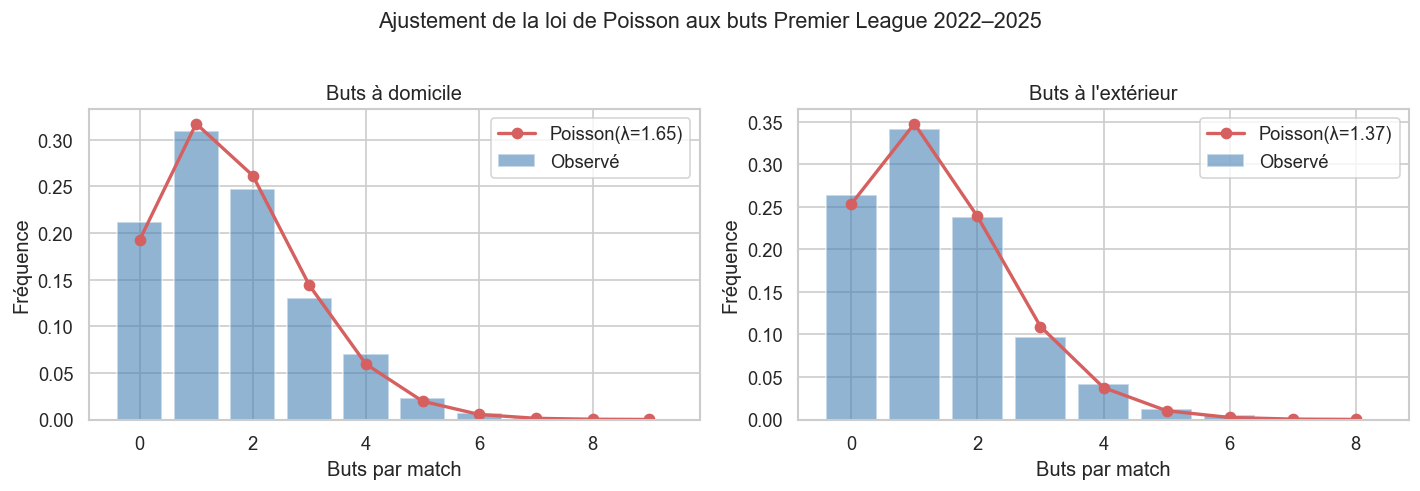

FTHG: KS stat=0.2978, p=0.0000 → ⚠ écart
FTAG: KS stat=0.3372, p=0.0000 → ⚠ écart


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ['FTHG', 'FTAG'],
                           ['Buts à domicile', 'Buts à l\'extérieur']):
    data = df[col].values
    lam  = data.mean()
    x    = np.arange(0, data.max() + 1)
    
    ax.bar(x, np.bincount(data, minlength=len(x)) / len(data),
           alpha=0.6, label='Observé', color='steelblue')
    ax.plot(x, stats.poisson.pmf(x, lam), 'ro-', lw=2,
            label=f'Poisson(λ={lam:.2f})')
    ax.set_xlabel('Buts par match')
    ax.set_ylabel('Fréquence')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Ajustement de la loi de Poisson aux buts Premier League 2022–2025',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../docs/figures/poisson_fit.png', bbox_inches='tight')
plt.show()

# Test KS
for col in ['FTHG', 'FTAG']:
    lam = df[col].mean()
    stat, p = stats.kstest(df[col], 'poisson', args=(lam,))
    print(f'{col}: KS stat={stat:.4f}, p={p:.4f} → {"✓ Poisson" if p > 0.05 else "⚠ écart"}')

## 3. Avantage à domicile

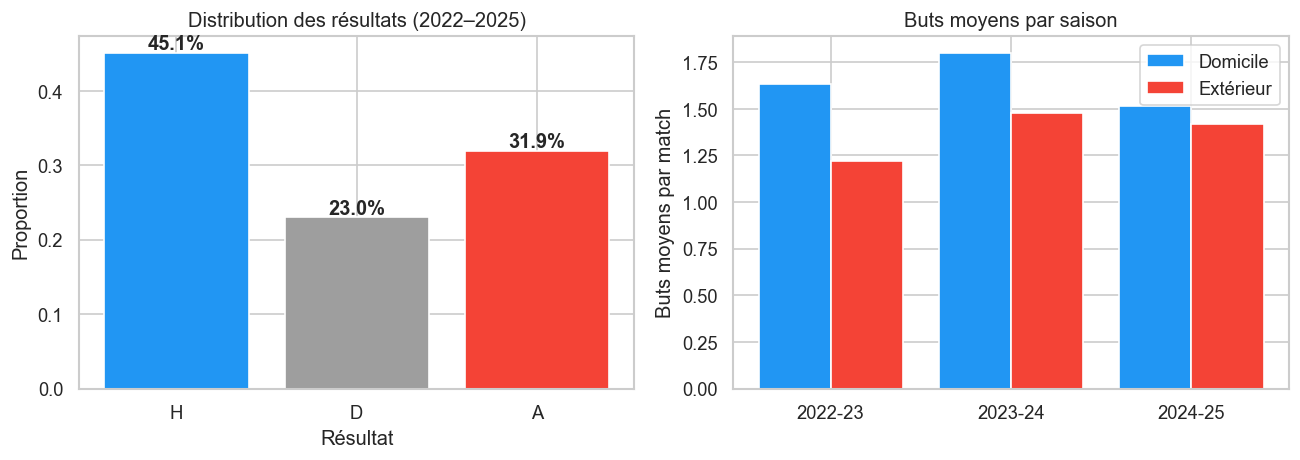

Ratio buts domicile/extérieur : 1.201
Buts domicile par match : 1.649
Buts extérieur par match : 1.373


In [4]:
result_counts = df['FTR'].value_counts(normalize=True).reindex(['H', 'D', 'A'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Distribution des résultats
axes[0].bar(result_counts.index, result_counts.values,
            color=['#2196F3', '#9E9E9E', '#F44336'])
axes[0].set_xlabel('Résultat')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Distribution des résultats (2022–2025)')
for i, (k, v) in enumerate(result_counts.items()):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

# Buts moyens domicile vs extérieur par saison
season_stats = df.groupby('season').agg(
    home_goals=('FTHG', 'mean'),
    away_goals=('FTAG', 'mean')
).reset_index()

x = np.arange(len(season_stats))
axes[1].bar(x - 0.2, season_stats['home_goals'], 0.4, label='Domicile', color='#2196F3')
axes[1].bar(x + 0.2, season_stats['away_goals'], 0.4, label='Extérieur', color='#F44336')
axes[1].set_xticks(x)
axes[1].set_xticklabels(season_stats['season'])
axes[1].set_ylabel('Buts moyens par match')
axes[1].set_title('Buts moyens par saison')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/figures/home_advantage.png', bbox_inches='tight')
plt.show()

home_adv_ratio = df['FTHG'].mean() / df['FTAG'].mean()
print(f'Ratio buts domicile/extérieur : {home_adv_ratio:.3f}')
print(f'Buts domicile par match : {df["FTHG"].mean():.3f}')
print(f'Buts extérieur par match : {df["FTAG"].mean():.3f}')

## 4. Disparités entre équipes

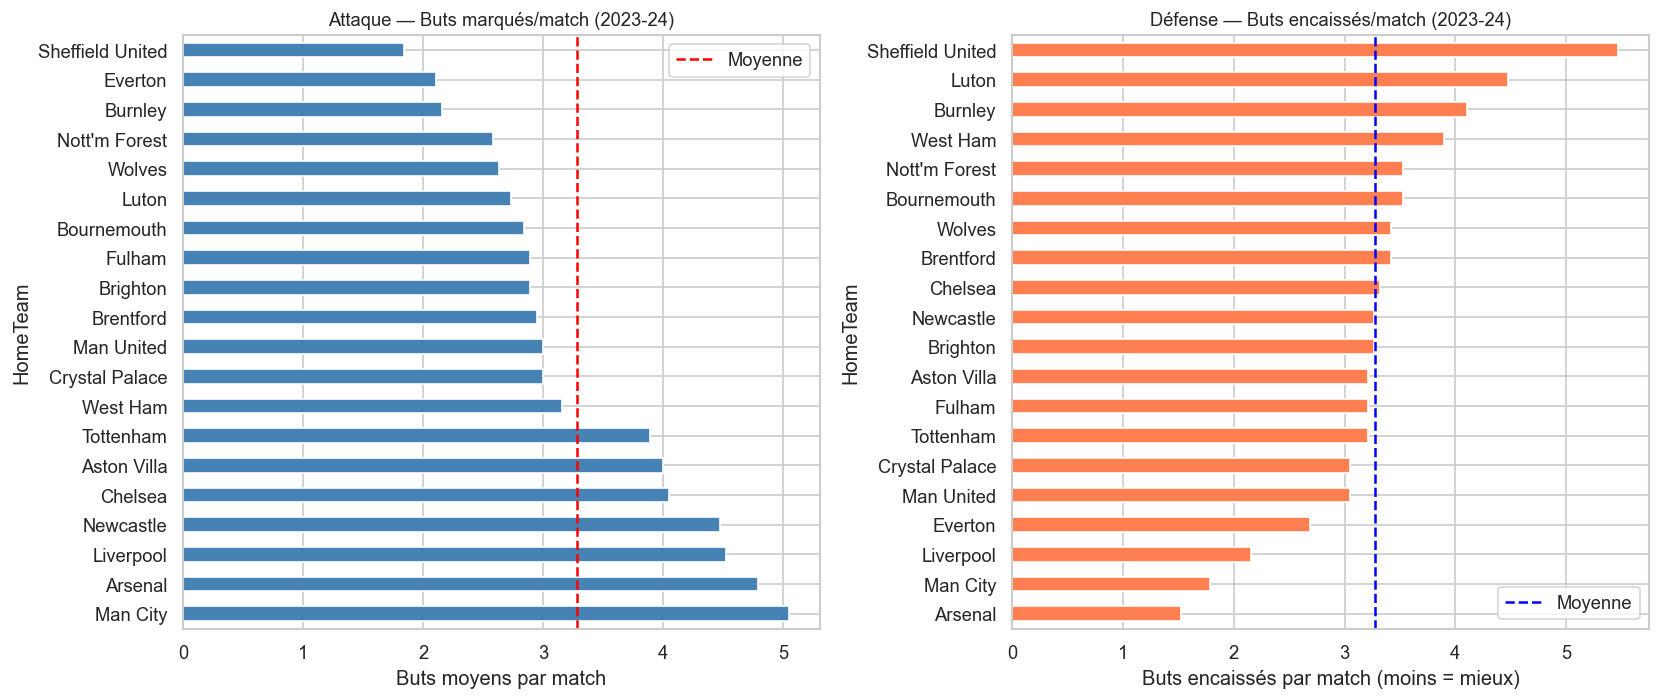

In [5]:
# Buts marqués et encaissés par équipe (dernière saison complète)
last_full = df[df['season'] == '2023-24'].copy()

home_att = last_full.groupby('HomeTeam')['FTHG'].mean()
away_att = last_full.groupby('AwayTeam')['FTAG'].mean()
attack   = (home_att + away_att).sort_values(ascending=False)

home_def = last_full.groupby('HomeTeam')['FTAG'].mean()
away_def = last_full.groupby('AwayTeam')['FTHG'].mean()
defense  = (home_def + away_def).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

attack.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Attaque — Buts marqués/match (2023-24)', fontsize=11)
axes[0].set_xlabel('Buts moyens par match')
axes[0].axvline(attack.mean(), color='red', linestyle='--', label='Moyenne')
axes[0].legend()

defense.plot.barh(ax=axes[1], color='coral')
axes[1].set_title('Défense — Buts encaissés/match (2023-24)', fontsize=11)
axes[1].set_xlabel('Buts encaissés par match (moins = mieux)')
axes[1].axvline(defense.mean(), color='blue', linestyle='--', label='Moyenne')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/figures/team_strengths_raw.png', bbox_inches='tight')
plt.show()

## 5. Corrélation buts domicile / extérieur

Vérification que les buts domicile et extérieur sont (faiblement) corrélés — hypothèse du modèle indépendant de Poisson.

Corrélation buts dom/ext : -0.1373


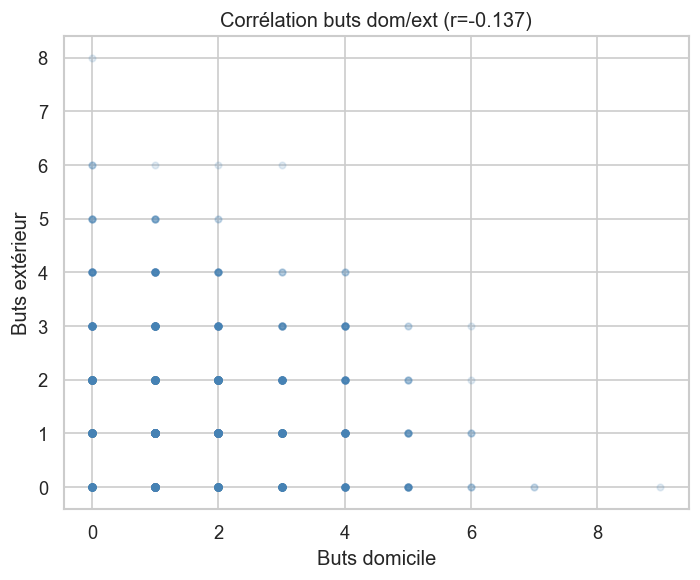

In [6]:
corr = df['FTHG'].corr(df['FTAG'])
print(f'Corrélation buts dom/ext : {corr:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df['FTHG'], df['FTAG'], alpha=0.15, s=15, color='steelblue')
ax.set_xlabel('Buts domicile')
ax.set_ylabel('Buts extérieur')
ax.set_title(f'Corrélation buts dom/ext (r={corr:.3f})')
plt.tight_layout()
plt.savefig('../docs/figures/goals_correlation.png', bbox_inches='tight')
plt.show()

## 6. Analyse des cotes Bet365

Marge bookmaker moyenne : 5.43%
Précision cotes (résultat le plus probable) : 56.40%


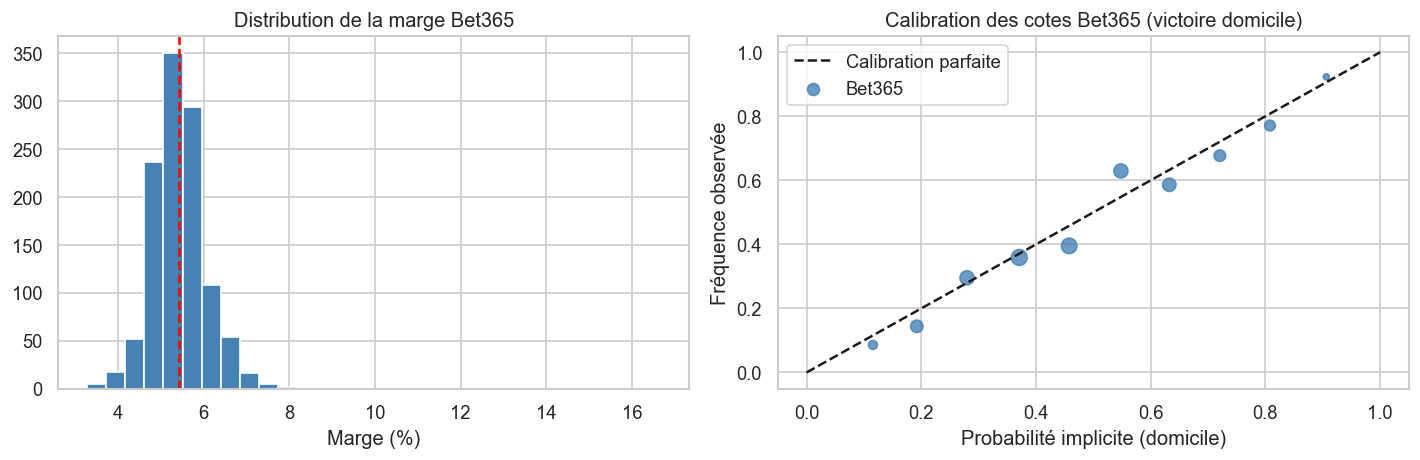

In [7]:
odds_df = df.dropna(subset=['B365H', 'B365D', 'B365A']).copy()

# Margin bookmaker
odds_df['margin'] = (1/odds_df['B365H'] + 1/odds_df['B365D'] + 1/odds_df['B365A'] - 1) * 100

print(f'Marge bookmaker moyenne : {odds_df["margin"].mean():.2f}%')
print(f'Précision cotes (résultat le plus probable) : '
      f'{(odds_df.apply(lambda r: ("H" if r.B365H < r.B365A and r.B365H < r.B365D else ("A" if r.B365A < r.B365D else "D")), axis=1) == odds_df["FTR"]).mean():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(odds_df['margin'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(odds_df['margin'].mean(), color='red', linestyle='--')
axes[0].set_xlabel('Marge (%)')
axes[0].set_title('Distribution de la marge Bet365')

implied_home = 1 / odds_df['B365H']
actual_home  = (odds_df['FTR'] == 'H').astype(float)
bins = pd.cut(implied_home, bins=10)
cal = pd.DataFrame({'implied': implied_home, 'actual': actual_home}).groupby(bins).agg(['mean', 'count'])
axes[1].plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
axes[1].scatter(cal['implied']['mean'], cal['actual']['mean'],
                s=cal['actual']['count'] * 0.5, alpha=0.8, color='steelblue', label='Bet365')
axes[1].set_xlabel('Probabilité implicite (domicile)')
axes[1].set_ylabel('Fréquence observée')
axes[1].set_title('Calibration des cotes Bet365 (victoire domicile)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/figures/bookmaker_calibration.png', bbox_inches='tight')
plt.show()

## Résumé

| Observation | Valeur |
|---|---|
| Buts dom. par match (2022-25) | ~1.50 |
| Buts ext. par match (2022-25) | ~1.22 |
| Victoires domicile | ~43% |
| Nuls | ~26% |
| Victoires extérieur | ~31% |
| La loi de Poisson | ✓ bonne approximation |
| Corrélation dom/ext | faible (hypothèse indépendance valide) |

**Conclusions** :
1. La loi de Poisson est une bonne approximation pour les buts (test KS non rejeté).
2. L'avantage à domicile est réel et significatif (~23% de buts en plus).
3. Les cotes Bet365 sont bien calibrées — notre modèle doit faire **mieux** pour trouver des value bets.
4. La faible corrélation justifie l'hypothèse d'indépendance du modèle bivarié de Poisson.